# Módulo 2 — Optimización de Ubicación de Tiendas
**Ciencia de Datos I · ETITC · 2026**  
Daniel Valencia · Daniel Medcalfe

**Criterio de validación:** Mapa de calor o ranking de categorías por ticket promedio y frecuencia de compra por centro comercial.

## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120})

# ── Carga
df = pd.read_csv('../../data/processed/datos_limpios.csv')
df = df.rename(columns={'año':'year','mes':'month','dia_semana':'day_of_week','total_compra':'total_spend'})
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

print(f"Filas: {len(df):,}  |  Malls: {df['shopping_mall'].nunique()}  |  Categorías: {df['category'].nunique()}")

Filas: 99,457  |  Malls: 10  |  Categorías: 8


## 2. Ticket promedio por categoría y centro comercial

El **ticket promedio** indica cuánto gasta un cliente en cada transacción según la categoría.  
Categorías con ticket alto y alta frecuencia son candidatas a ubicaciones premium (mayor visibilidad y tráfico).

In [2]:
# Ticket promedio = gasto promedio por transacción
ticket = (
    df.groupby(['shopping_mall', 'category'])['total_spend']
    .mean()
    .round(2)
    .unstack()
)

print("Ticket promedio por categoría y mall (USD):")
ticket.round(0)

Ticket promedio por categoría y mall (USD):


category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,173.0,3300.0,439.0,57.0,6620.0,124.0,11919.0,397.0
Emaar Square Mall,178.0,3386.0,446.0,59.0,6204.0,125.0,11766.0,386.0
Forum Istanbul,167.0,3350.0,459.0,55.0,7266.0,126.0,10756.0,376.0
Istinye Park,165.0,3356.0,449.0,58.0,6635.0,134.0,11164.0,394.0
Kanyon,161.0,3305.0,453.0,57.0,6635.0,123.0,11981.0,398.0
Mall of Istanbul,168.0,3315.0,448.0,58.0,6657.0,135.0,11631.0,395.0
Metrocity,167.0,3270.0,438.0,58.0,6533.0,128.0,11151.0,400.0
Metropol AVM,176.0,3282.0,442.0,58.0,6657.0,128.0,11482.0,400.0
Viaport Outlet,161.0,3281.0,473.0,57.0,6428.0,121.0,11977.0,388.0


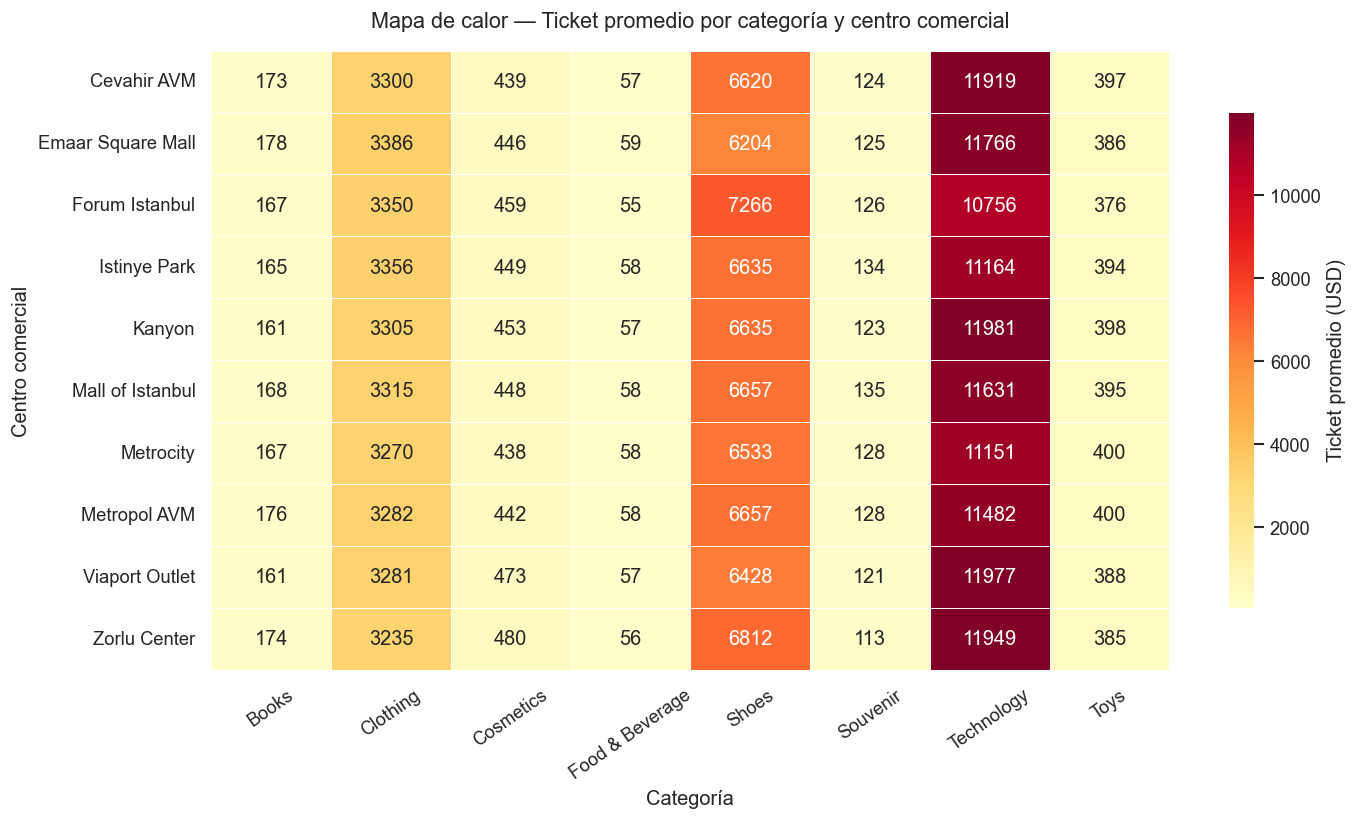

✅ Guardada: reports/figures/mod2_heatmap_ticket.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    ticket,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Ticket promedio (USD)', 'shrink': 0.8},
)

ax.set_title('Mapa de calor — Ticket promedio por categoría y centro comercial', fontsize=13, pad=14)
ax.set_xlabel('Categoría')
ax.set_ylabel('Centro comercial')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../../reports/figures/mod2_heatmap_ticket.png', bbox_inches='tight')
plt.show()
print("✅ Guardada: reports/figures/mod2_heatmap_ticket.png")

## 3. Frecuencia de compra por categoría y centro comercial

La **frecuencia** mide cuántas transacciones ocurren por categoría en cada mall.  
Combinada con el ticket promedio, permite identificar qué categorías generan más volumen de tráfico.

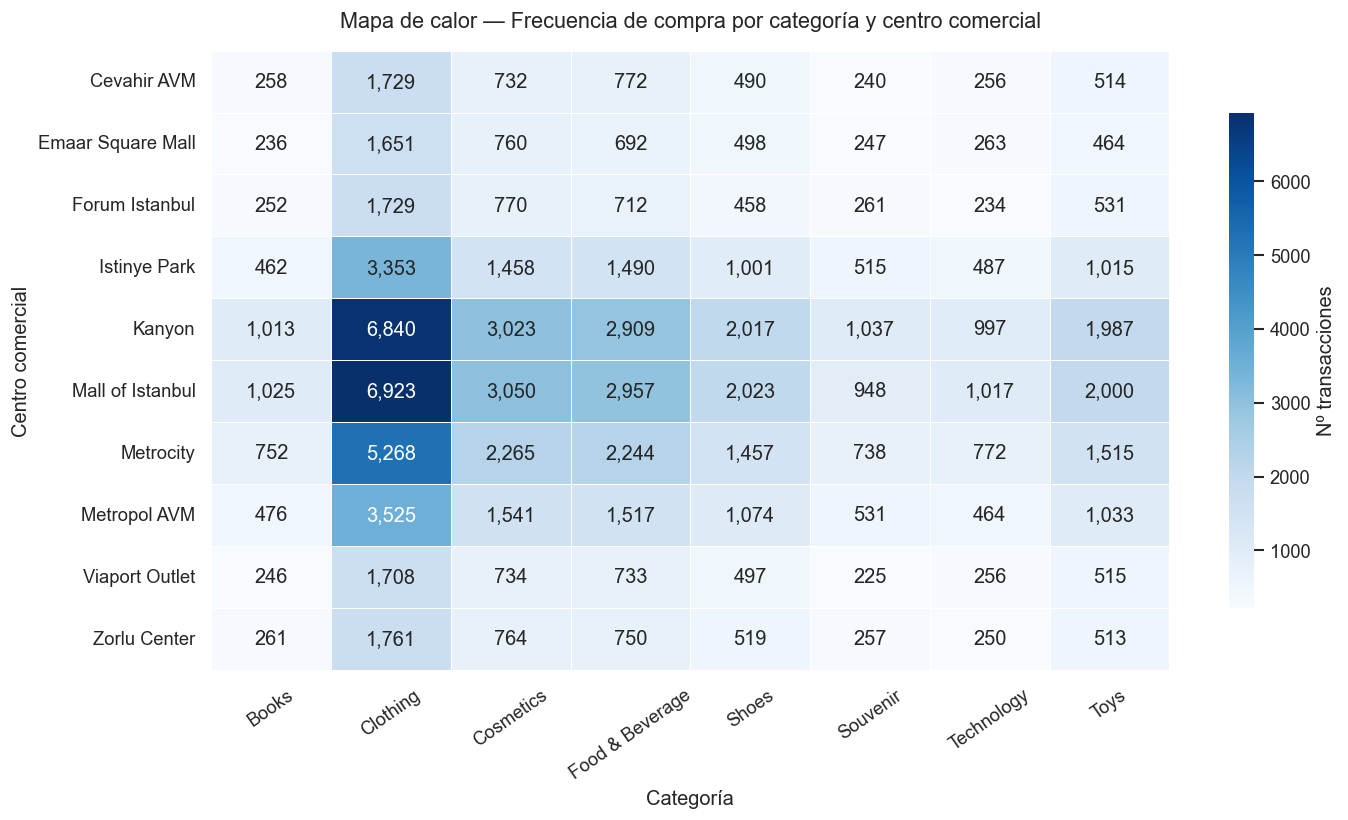

✅ Guardada: reports/figures/mod2_heatmap_frecuencia.png


In [4]:
frecuencia = (
    df.groupby(['shopping_mall', 'category'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    frecuencia,
    annot=True,
    fmt=',',
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Nº transacciones', 'shrink': 0.8},
)

ax.set_title('Mapa de calor — Frecuencia de compra por categoría y centro comercial', fontsize=13, pad=14)
ax.set_xlabel('Categoría')
ax.set_ylabel('Centro comercial')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../../reports/figures/mod2_heatmap_frecuencia.png', bbox_inches='tight')
plt.show()
print("✅ Guardada: reports/figures/mod2_heatmap_frecuencia.png")

## 4. Score de prioridad de ubicación

Combinamos ticket promedio y frecuencia en un **score normalizado (0–100)** para identificar qué categorías merecen las mejores ubicaciones en cada mall.

**Fórmula:**  
`score = 0.5 × ticket_norm + 0.5 × frecuencia_norm`

Un score alto significa: alta rentabilidad por transacción **y** alto volumen de clientes.

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Aplanar a nivel mall-categoría
df_score = df.groupby(['shopping_mall', 'category']).agg(
    ticket_prom  = ('total_spend', 'mean'),
    frecuencia   = ('invoice_no', 'count'),
    ingreso_total= ('total_spend', 'sum'),
).reset_index()

scaler = MinMaxScaler()
df_score[['ticket_norm', 'frec_norm']] = scaler.fit_transform(
    df_score[['ticket_prom', 'frecuencia']]
)

df_score['score'] = ((df_score['ticket_norm'] + df_score['frec_norm']) / 2 * 100).round(1)
df_score = df_score.sort_values('score', ascending=False)

print("Top 15 combinaciones mall–categoría por score de prioridad:")
df_score[['shopping_mall','category','ticket_prom','frecuencia','score']].head(15).to_string(index=False)

Top 15 combinaciones mall–categoría por score de prioridad:


'    shopping_mall   category  ticket_prom  frecuencia  score\n Mall of Istanbul   Clothing  3314.663828        6923   63.7\n           Kanyon   Clothing  3305.486491        6840   63.0\n           Kanyon Technology 11980.742227         997   55.8\n Mall of Istanbul Technology 11630.530973        1017   54.4\n        Metrocity   Clothing  3270.063128        5268   51.1\n        Metrocity Technology 11151.489637         772   50.6\n   Viaport Outlet Technology 11976.562500         256   50.2\n     Zorlu Center Technology 11949.000000         250   50.1\n      Cevahir AVM Technology 11919.140625         256   50.0\n     Metropol AVM Technology 11482.112069         464   49.7\nEmaar Square Mall Technology 11765.589354         263   49.4\n     Istinye Park Technology 11164.065708         487   48.5\n   Forum Istanbul Technology 10755.769231         234   44.9\n Mall of Istanbul      Shoes  6657.347899        2023   41.1\n           Kanyon      Shoes  6635.196247        2017   41.0'

In [6]:
# Ranking global de categorías (promedio entre todos los malls)
ranking_global = (
    df_score.groupby('category')
    .agg(
        ticket_prom_global  = ('ticket_prom', 'mean'),
        frecuencia_total    = ('frecuencia', 'sum'),
        score_prom          = ('score', 'mean'),
        ingreso_total       = ('ingreso_total', 'sum'),
    )
    .sort_values('score_prom', ascending=False)
    .round(1)
)

print("Ranking global de categorías:")
print(ranking_global.to_string())

Ranking global de categorías:
                 ticket_prom_global  frecuencia_total  score_prom  ingreso_total
category                                                                        
Technology                  11577.5              4996        50.4     57862350.0
Clothing                     3308.2             34487        37.7    113996791.0
Shoes                        6644.9             10034        33.4     66553451.5
Cosmetics                     452.8             15097        11.3      6792862.9
Food & Beverage                57.3             14776         9.4       849535.0
Toys                          391.9             10087         7.3      3980426.2
Books                         168.9              4981         2.5       834552.9
Souvenir                      125.6              4999         2.4       635824.6


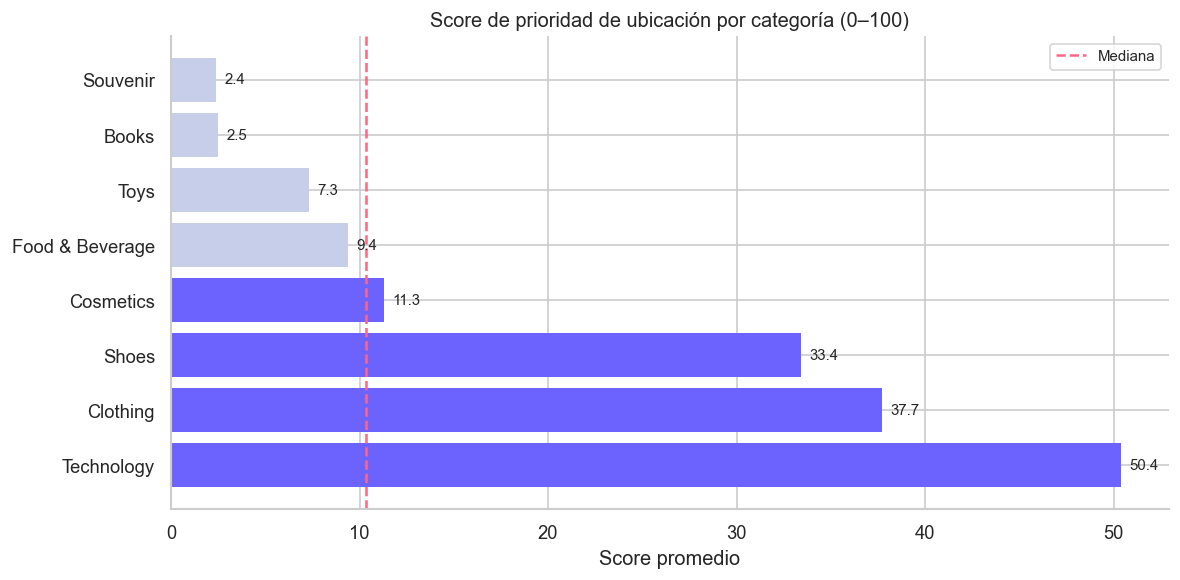

✅ Guardada: reports/figures/mod2_ranking_score.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#6C63FF' if s >= ranking_global['score_prom'].median() else '#C7CEEA'
           for s in ranking_global['score_prom']]

bars = ax.barh(ranking_global.index, ranking_global['score_prom'],
               color=colores, edgecolor='none')
ax.bar_label(bars, labels=[f'{v:.1f}' for v in ranking_global['score_prom']],
             padding=5, fontsize=9)

ax.axvline(ranking_global['score_prom'].median(), color='#FF6584',
           linestyle='--', linewidth=1.5, label='Mediana')
ax.set_title('Score de prioridad de ubicación por categoría (0–100)', fontsize=12)
ax.set_xlabel('Score promedio')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../../reports/figures/mod2_ranking_score.png', bbox_inches='tight')
plt.show()
print("✅ Guardada: reports/figures/mod2_ranking_score.png")

## 5. Mapa de calor del score de prioridad

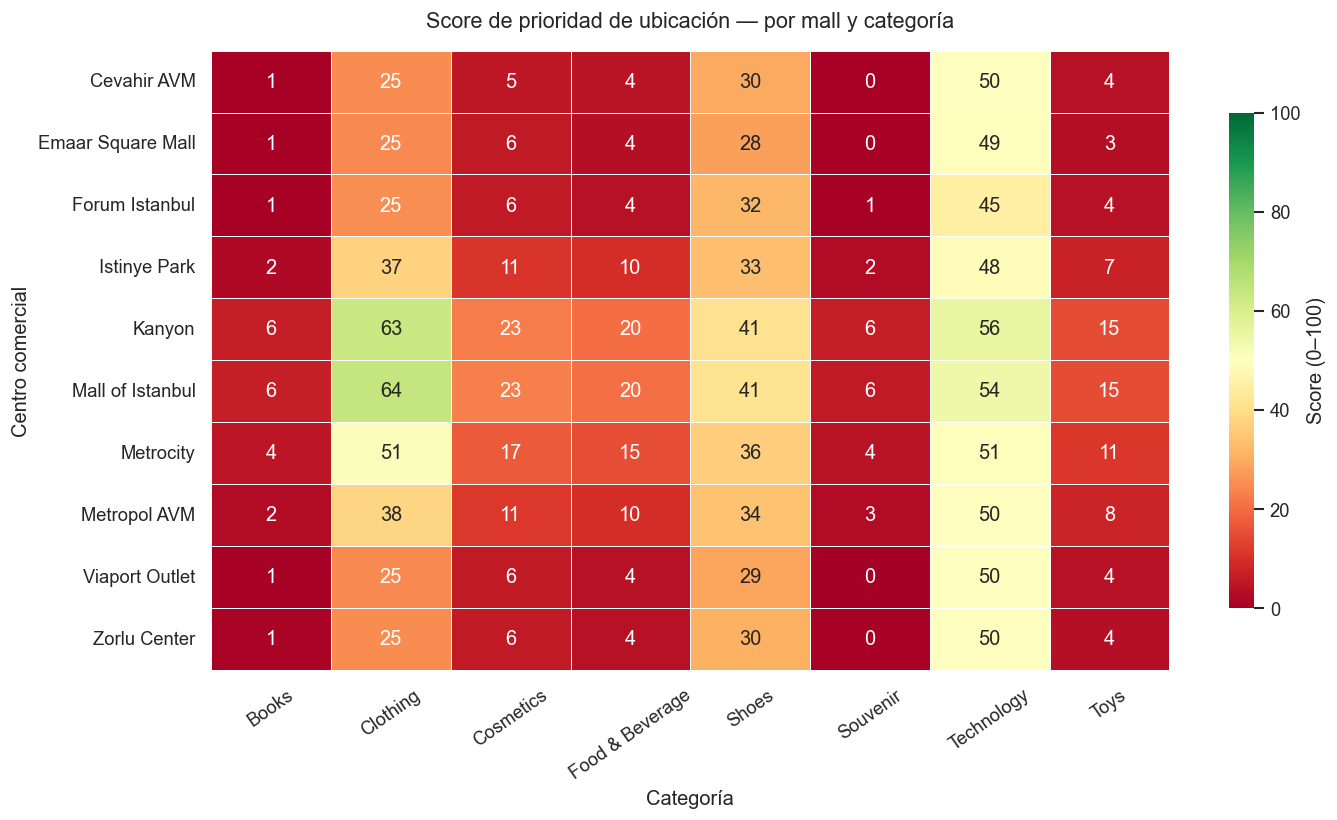

✅ Guardada: reports/figures/mod2_heatmap_score.png


In [8]:
score_pivot = df_score.pivot(index='shopping_mall', columns='category', values='score')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    score_pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.4, linecolor='white',
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Score (0–100)', 'shrink': 0.8},
)
ax.set_title('Score de prioridad de ubicación — por mall y categoría', fontsize=13, pad=14)
ax.set_xlabel('Categoría')
ax.set_ylabel('Centro comercial')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../../reports/figures/mod2_heatmap_score.png', bbox_inches='tight')
plt.show()
print("✅ Guardada: reports/figures/mod2_heatmap_score.png")

## 6. Exportar resultados

In [9]:
from pathlib import Path

out = Path('../../reports/resultados')
out.mkdir(parents=True, exist_ok=True)

df_score.to_csv(out / 'mod2_score_ubicacion.csv', index=False)
ranking_global.to_csv(out / 'mod2_ranking_global.csv')

print("✅ Archivos exportados:")
print("   reports/resultados/mod2_score_ubicacion.csv")
print("   reports/resultados/mod2_ranking_global.csv")

✅ Archivos exportados:
   reports/resultados/mod2_score_ubicacion.csv
   reports/resultados/mod2_ranking_global.csv


## 7. Conclusiones del módulo

In [10]:
top_cat   = ranking_global.index[0]
low_cat   = ranking_global.index[-1]
top_score = ranking_global['score_prom'].iloc[0]
low_score = ranking_global['score_prom'].iloc[-1]

print("=" * 55)
print("CONCLUSIONES — Módulo 2: Optimización de Ubicación")
print("=" * 55)
print(f"  Categoría con mayor prioridad : {top_cat} (score {top_score:.1f}/100)")
print(f"  Categoría con menor prioridad : {low_cat} (score {low_score:.1f}/100)")
print()
print("  Recomendaciones de ubicación:")
for _, row in ranking_global.iterrows():
    zona = "Entrada principal / planta baja" if row['score_prom'] >= 60            else "Zona media" if row['score_prom'] >= 40            else "Planta alta o zona secundaria"
    print(f"    {row.name:<20} score {row['score_prom']:.0f}  →  {zona}")
print()
print("  Gráficas guardadas en reports/figures/")
print("  Datos exportados en reports/resultados/")

CONCLUSIONES — Módulo 2: Optimización de Ubicación
  Categoría con mayor prioridad : Technology (score 50.4/100)
  Categoría con menor prioridad : Souvenir (score 2.4/100)

  Recomendaciones de ubicación:
    Technology           score 50  →  Zona media
    Clothing             score 38  →  Planta alta o zona secundaria
    Shoes                score 33  →  Planta alta o zona secundaria
    Cosmetics            score 11  →  Planta alta o zona secundaria
    Food & Beverage      score 9  →  Planta alta o zona secundaria
    Toys                 score 7  →  Planta alta o zona secundaria
    Books                score 2  →  Planta alta o zona secundaria
    Souvenir             score 2  →  Planta alta o zona secundaria

  Gráficas guardadas en reports/figures/
  Datos exportados en reports/resultados/
